In [803]:
from LiouvilleLanczos.Quantum_computer.Hamiltonian import Line_Hubbard, BoundaryCondition
from qiskit_nature.second_q.operators import FermionicOp
from LiouvilleLanczos.Quantum_computer.QC_lanczos import Liouvillian_spo, sum_spo, relative_simplify_spo, separate_imag, dump_qpu_error , inner_product_spo
from qiskit_ibm_runtime import RuntimeJobFailureError
from typing import Optional
from LiouvilleLanczos.Lanczos import Lanczos as LCZ
import numpy as np
from qiskit.circuit.library import real_amplitudes
from qiskit_aer.primitives import EstimatorV2 as AerEstimatorV2
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from LiouvilleLanczos.Green import CF_Green as CF
from LiouvilleLanczos.Lanczos_components import Inner_product as Base_inner_product
from qiskit.primitives import BaseEstimatorV2
from qiskit.circuit.library import UnitaryGate
import matplotlib.pyplot as plt

MAPPER = JordanWignerMapper()

In [804]:
def to_sparse_pauli(op):
    """
    Convert FermionicOp -> SparsePauliOp.
    Leave SparsePauliOp unchanged.
    """
    if isinstance(op, SparsePauliOp):
        return op

    if isinstance(op, FermionicOp):
        return MAPPER.map(op).simplify(atol=1e-12)

    raise TypeError(f"Unsupported operator type: {type(op)}")

def exact_gs_circuit_two_sites():
    bt = 0.7854074074074073
    GS_analytical = QuantumCircuit(4)
    GS_analytical.h(0)
    GS_analytical.x(1)
    GS_analytical.cx(0,1)
    GS_analytical.ry(bt,2)
    GS_analytical.x(3)
    GS_analytical.cx(2,3)
    GS_analytical.cx(1,3)
    GS_analytical.cx(1,2)
    GS_analytical.cz(1,2)
    GS_analytical.swap(1,2)
    return GS_analytical



Fermionic mode 0 = qubit 0
Fermionic mode 1 = qubit 1 and so on

$$H = \sum_{i, j}\sum_{\sigma = \uparrow, \downarrow} t_{i, j} c_{i, \sigma}^\dagger c_{j, \sigma} + U \sum_{i} n_{i, \uparrow} n_{i, \downarrow}$$

This is (up,down,up,down,up,down)

In [805]:
U = 4 
q = 6

Ham = Line_Hubbard(-1,U/2,U,int(q/2),boundary_condition=BoundaryCondition.OPEN)

C0 = FermionicOp(
    {
        "+_0": 1,
    },
    num_spin_orbitals=q,
)


for p in range(6):
    n_p = FermionicOp({f"+_{p} -_{p}": 1.0}, num_spin_orbitals=6)
    print(p, MAPPER.map(n_p))



print(Ham)
H = to_sparse_pauli(Ham)
C0 = to_sparse_pauli(C0)



0 SparsePauliOp(['IIIIII', 'IIIIIZ'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
1 SparsePauliOp(['IIIIII', 'IIIIZI'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
2 SparsePauliOp(['IIIIII', 'IIIZII'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
3 SparsePauliOp(['IIIIII', 'IIZIII'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
4 SparsePauliOp(['IIIIII', 'IZIIII'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
5 SparsePauliOp(['IIIIII', 'ZIIIII'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
Fermionic Operator
number spin orbitals=6, number terms=17
  -1 * ( +_0 -_2 )
+ 1 * ( -_0 +_2 )
+ -1 * ( +_2 -_4 )
+ 1 * ( -_2 +_4 )
+ -2.0 * ( +_0 -_0 )
+ -2.0 * ( +_2 -_2 )
+ -2.0 * ( +_4 -_4 )
+ -1 * ( +_1 -_3 )
+ 1 * ( -_1 +_3 )
+ -1 * ( +_3 -_5 )
+ 1 * ( -_3 +_5 )
+ -2.0 * ( +_1 -_1 )
+ -2.0 * ( +_3 -_3 )
+ -2.0 * ( +_5 -_5 )
+ 4 * ( +_0 -_0 +_1 -_1 )
+ 4 * ( +_2 -_2 +_3 -_3 )
+ 4 * ( +_4 -_4 +_5 -_5 )


In [806]:
def hubbard(hop=np.array([[0, 1], [1, 0]]), u=4, mu=None):
    n = len(hop)
    if mu is None:
        mu = u / 2
    hopping = FermionicOp(
        {
            f"+_{i+m} -_{j+m}": hop[i, j]
            for m in [0, n]
            for i in range(n)
            for j in range(n)
            if hop[i, j] != 0
        },
        num_spin_orbitals=2 * n,
    )
    occupation = FermionicOp(
        {f"+_{i} -_{i}": 1 for i in range(2 * n)}, num_spin_orbitals=2 * n
    )
    interaction = FermionicOp(
        {f"+_{i} +_{i+n} -_{i+n} -_{i}": 1 for i in range(n)}, num_spin_orbitals=2 * n
    )
    return MAPPER.map(-hopping + u * interaction - mu * occupation)


n = 3
hopping = np.diag(np.ones(n - 1), 1) + np.diag(np.ones(n - 1), -1)
hamiltonian = hubbard(hopping, U, mu=U/2)
eigvals, eigvecs = np.linalg.eigh(hamiltonian.to_matrix())

vqe_hubbard_3sites = real_amplitudes(num_qubits=6, reps=11, entanglement='linear')
vqe_hubbard_3sites = vqe_hubbard_3sites.assign_parameters(np.array([
    5.246829583426229, 1.8445563598975319, 6.249341224922228, 5.547426630865061, 4.204112886091582,
    4.7123853975763605, 0.27755320293694075, 0.32924783165591026, 1.5501725153481376, 0.354654347037912,
    1.4126950505240836, 7.524339982913663e-06, 1.5454883723953319, 4.008676262413297, 0.5471153440483539,
    0.6439116484454839, 5.416150750408826, 3.141590029386429, 1.121133004167295, 4.919561698711213,
    4.354025416990712, 4.348236205036469, 0.1627483139705849, 6.890458045940891e-06, 1.5750620500544459,
    3.925552761663296, 2.4735512439001406, 3.564021121427497, 2.1847082492649674, 3.1415875290047737,
    5.145406231818936, 3.082671747231, 4.755880471423207, 1.5314536798535008, 5.823307617043694,
    3.1416008591215223, 5.901892324799543, 1.4437881974849553, 4.645825634069647, 1.6387913496744664,
    5.2749649006268555, 1.1584242198623043e-05, 2.4788427008935474, 5.261826591438184, 5.982045041499495,
    2.24084148657242, 1.3918515401467277, 3.141590524117431, 2.6212585750135275, 0.0, 4.140488402169957,
    0.6887497275343819, 0.16071147559368984, 4.712382212081382, 5.6131238667553776, 0.2442058266515827,
    2.815716430300995, 1.696363607754504, 4.71239011907928, 6.283185307179586, 2.0669264858298853,
    2.441456446485303, 1.273233624886327, 2.646377569674503, 0.957628396457077, 1.8447208439653136,
    5.224543370694376, 1.583011829806925, 6.116083873171027, 6.0304071284479774e-06, 1.570785721175754,
    2.9229147479846883e-06
]))

vqe_energy = AerEstimatorV2().run([(vqe_hubbard_3sites, hamiltonian)]).result()[0].data.evs
vqe_state_vector = Statevector.from_instruction(vqe_hubbard_3sites)
vqe_fidelities = [
    float(np.abs(np.vdot(eigvecs[:, 0], vqe_state_vector)) ** 2),
    float(np.abs(np.vdot(eigvecs[:, 1], vqe_state_vector)) ** 2),
]

print(vqe_energy, eigvals[0], vqe_energy/eigvals[0], vqe_fidelities)


-7.236067977398462 -7.23606797749979 0.9999999999859969 [1.8090775811196553e-12, 0.9999999999494498]


In [807]:
FSWAP = np.array([
            [1, 0, 0,  0],
            [0, 0, -1,  0],
            [0, 1, 0,  0],
            [0, 0, 0, 1],
        ], dtype=complex)
fswap_gate = UnitaryGate(FSWAP, label="FSWAP")

print("F^dag @ F = I? " , np.allclose(FSWAP.conj().T @ FSWAP, np.eye(4)))

F^dag @ F = I?  True


In [808]:
from LiouvilleLanczos.Lanczos_components import Inner_product,Liouvillian,Summation

class Lanczos():
    def __init__(self,inner_product:Inner_product,liouvillian:Liouvillian,sum:Summation,epsilon=1e-13 ,logger = None):
        self.inner_prod  = inner_product
        self.Liouvillian = liouvillian
        self.sum = sum
        self.epsilon = epsilon
    def polynomial_hybrid(self, H, f_0, other_vectors, max_k, min_b=1e-10):
        assert max_k > 1, "No checkpoint! use max_k > 1 to start computation"  # Make sure Lanczos runs for at least 2 iterations

        i = 0  # Initialize the Lanczos iteration index

        b = [np.sqrt(self.inner_prod(f_0, f_0, real_result=True, Name="b_0"))]  # Compute initial norm b_0 = sqrt(<f_0, f_0>)

        f_i = f_0 / b[-1]  # Normalize the initial vector f_0 so that f_i has norm 1

        mi = [
            [
                self.inner_prod(o, f_i, real_result=False, Name=f"m{m}_{0}")
                for m, o in enumerate(other_vectors)
            ]
        ]  # Compute overlaps/moments <o_m, f_0> for all extra vectors using normalized f_i

        f_ip = self.Liouvillian(-H, f_i)  # Apply the Liouvillian to the current Lanczos vector f_i

        a_i = self.inner_prod(f_ip, f_i, real_result=True, Name="a_0")  # Compute first diagonal Lanczos coefficient a_0 = <L f_0, f_0>

        a = [a_i]  # Store the first diagonal coefficient

        start = 1  # The next Lanczos iteration will start at i = 1

        f_ip = self.sum(f_ip, -a_i * f_i)  # Orthogonalize L f_i against f_i by subtracting a_i f_i

        b_ip = np.sqrt(self.inner_prod(f_ip, f_ip, real_result=True, Name="b_1"))  # Compute b_1 = norm of the residual vector

        f_ip = f_ip / b_ip  # Normalize the residual to get the next Lanczos basis vector

        f_i, f_im = f_ip, f_i  # Update: f_i becomes the new current vector, f_im stores the previous vector

        for i in range(start, max_k):  # Main Lanczos loop from i = 1 up to max_k - 1
            
            if b_ip < min_b:  # Stop if the previous off-diagonal coefficient is too small
                return a, b, mi  # Return the coefficients and moments computed so far

            mi.append(
                [
                    self.inner_prod(o, f_i, real_result=False, Name=f"m{m}_{i}")
                    for m, o in enumerate(other_vectors)
                ]
            )  # Compute overlaps/moments <o_m, f_i> for the current Lanczos vector

            f_ip = self.Liouvillian(-H, f_i)  # Apply the Liouvillian to the current vector f_i

            try:
                a_i = self.inner_prod(f_ip, f_i, real_result=True, Name=f"a_{i}")  # Compute diagonal coefficient a_i = <L f_i, f_i>

                a.append(a_i)  # Store a_i

            except Exception as e:  # Catch failure in computing a_i
                print(f"early termination a at iteration {i}")  # Print where the failure happened
                print(e)  # Print the actual exception
                return a, b, mi  # Return coefficients and moments computed so far

            b.append(b_ip)  # Store the previous off-diagonal coefficient b_i

            f_ip = self.sum(f_ip, -a_i * f_i, -b[-1] * f_im)  # Orthogonalize against f_i and f_{i-1}

            try:
                b2 = self.inner_prod(f_ip, f_ip, real_result=True, Name=f"b^2_{i+1}")  # Compute squared norm of the new residual

                assert np.real(b2) > self.epsilon, f"b^2={b2} is smaller than {self.epsilon}, terminating"  # Stop if residual norm is too small

                b_ip = np.sqrt(b2)  # Compute next off-diagonal coefficient b_{i+1}

            except Exception as e:  # Catch failure in computing b_{i+1}
                print(f"early termination b at iteration {i}")  # Print where the failure happened
                print(e)  # Print the actual exception
                return a, b, mi  # Return coefficients and moments computed so far

            f_ip = f_ip / b_ip  # Normalize residual to get the next Lanczos vector

            f_i, f_im = f_ip, f_i  # Shift vectors: new current is f_ip, old current becomes previous
            
            if hasattr(self.inner_prod, "fswap"):
                self.inner_prod.fswap = not self.inner_prod.fswap

        return a, b, mi  # Return diagonal coefficients a, off-diagonal coefficients b, and moments mi
         
    def __call__(self,H,f_0,max_k,min_b=1e-10):
        a,b,_ = self.polynomial_hybrid(H,f_0,[],max_k,min_b)
        return a,b
    


In [809]:
class inner_product_sum(Base_inner_product):
    """
    Operator Inner product implementation for sparse pauli operators.
    Compute $\\bra{\\psi} \\rho \\{A,B^\\dagger \\} \\ket{\\psi}$
    where $\\ket{\\psi}$ is a quantum state specified by a quantum circuit.
    $A$ and $B$ are quantum operators specified by sparse pauli operators.
    Uses ibm runtime estimatorV2 interface to submit tasks to quantum computers.
    """
    def __init__(self, state: QuantumCircuit, estimator: BaseEstimatorV2, epsilon: int):
        """
        Constructor for the inner product.
        requires
        - state: a quantum circuit that produce a desired state.
        - estimator: an EstimatorV2 estimator to submit jobs to a quantum computer.
        - epsilon: target accuracy, smaller relative values are truncated. 
        """
        self.state = state
        self.estimator = estimator
        self.eps = epsilon
        self.GS_I = state.copy()
        self.GS_F = state.copy()
        self.construct_gates()

    def construct_gates(self):
        for i in range(int((self.state.num_qubits)/2)):
            self.GS_F.append(fswap_gate,[(i*2),(i*2)+1])

        
        
    def __call__(self,A:SparsePauliOp,B:SparsePauliOp,real_result:bool=False,Name:Optional[str]=None):
        """
        compute the innerproduct between that A and B operator.
        set real_result to True to bypass computation of an imaginary part in the result.
        Set a Name to easily identify the associated jobs on IBM quantum.
        """
        return 0.5 * (self.inner(self.GS_I,A,B,real_result=real_result) + self.inner(self.GS_F,A,B,real_result=real_result))
        
        

    def inner(self,GS,A:SparsePauliOp,B:SparsePauliOp,real_result:bool=False,Name:Optional[str]=None):
        Bc = B.adjoint()
        f = A@Bc+Bc@A
        f = relative_simplify_spo(f,self.eps)
        obs_real, obs_imag = separate_imag(f)        
        out = complex(0)
        if any(np.abs(obs_real.coeffs)>=self.eps):
            isa_obs_real = obs_real.apply_layout(GS.layout)
            try:
                out += np.real(self.estimator.run([(GS, isa_obs_real)]).result()[0].data.evs)
            except RuntimeJobFailureError as e:
                dump_qpu_error((GS, isa_obs_real), e, note="real")

        if not real_result and any(np.abs(obs_imag.coeffs)>=self.eps):
            isa_obs_imag = obs_imag.apply_layout(GS.layout)
            try:
                out_imag = np.real(self.estimator.run([(GS,isa_obs_imag)]).result()[0].data.evs)
            except RuntimeJobFailureError as e:
                dump_qpu_error((GS, isa_obs_imag), e, note="imag")
                
            out += out_imag * 1j
        return out

In [810]:
class inner_fswap(Base_inner_product):
    """
    Operator Inner product implementation for sparse pauli operators.
    Compute $\\bra{\\psi} \\rho \\{A,B^\\dagger \\} \\ket{\\psi}$
    where $\\ket{\\psi}$ is a quantum state specified by a quantum circuit.
    $A$ and $B$ are quantum operators specified by sparse pauli operators.
    Uses ibm runtime estimatorV2 interface to submit tasks to quantum computers.
    """
    def __init__(self, state: QuantumCircuit, estimator: BaseEstimatorV2, epsilon: int):
        """
        Constructor for the inner product.
        requires
        - state: a quantum circuit that produce a desired state.
        - estimator: an EstimatorV2 estimator to submit jobs to a quantum computer.
        - epsilon: target accuracy, smaller relative values are truncated. 
        """
        self.state = state
        self.estimator = estimator
        self.eps = epsilon
        self.fswap = False
        self.GS_I = state.copy()
        self.GS_F = state.copy()
        self.construct_gates()

    def construct_gates(self):
        for i in range(int((self.state.num_qubits)/2)):
            self.GS_F.append(fswap_gate,[(i*2),(i*2)+1])
        
    def __call__(self,A:SparsePauliOp,B:SparsePauliOp,real_result:bool=False,Name:Optional[str]=None):
        """
        compute the innerproduct between that A and B operator.
        set real_result to True to bypass computation of an imaginary part in the result.
        Set a Name to easily identify the associated jobs on IBM quantum.
        """
        if self.fswap:
            GS = self.GS_F
        else:
            GS = self.GS_I
        Bc = B.adjoint()
        f = A@Bc+Bc@A
        f = relative_simplify_spo(f,self.eps)
        obs_real, obs_imag = separate_imag(f)        
        out = complex(0)
        if any(np.abs(obs_real.coeffs)>=self.eps):
            isa_obs_real = obs_real.apply_layout(GS.layout)
            try:
                out += np.real(self.estimator.run([(GS, isa_obs_real)]).result()[0].data.evs)
            except RuntimeJobFailureError as e:
                dump_qpu_error((GS, isa_obs_real), e, note="real")

        if not real_result and any(np.abs(obs_imag.coeffs)>=self.eps):
            isa_obs_imag = obs_imag.apply_layout(GS.layout)
            try:
                out_imag = np.real(self.estimator.run([(GS,isa_obs_imag)]).result()[0].data.evs)
            except RuntimeJobFailureError as e:
                dump_qpu_error((GS, isa_obs_imag), e, note="imag")
                
            out += out_imag * 1j
        return out

In [811]:
if q == 4:
    GS1 = exact_gs_circuit_two_sites()
else:
    GS1 = vqe_hubbard_3sites.copy()

GS2 = GS1.copy()
for i in range(int(GS2.num_qubits/2)):
    GS2.append(fswap_gate, [i*2, (i*2)+1])


In [812]:
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import Statevector
estimator = StatevectorEstimator()

res1 = estimator.run([(GS1,H)])
res2 = estimator.run([(GS2,H)])

SG1 = Statevector(GS1).data
SG2 = Statevector(GS2).data
print("orthogonal:" , np.allclose(SG1.T @ SG2, 0, atol=1e-10))
print("energies of 2 ground states equal?",res1.result()[0].data.evs == res2.result()[0].data.evs)


orthogonal: True
energies of 2 ground states equal? True


## Normal Lanczos Normal inner product SPO one for GS and one for FSWAP GS

In [813]:
eps = 1e-6
lanczos1 = LCZ(inner_product_spo(GS1,AerEstimatorV2(),eps),Liouvillian_spo(eps),sum_spo(eps))
lanczos2 = LCZ(inner_product_spo(GS2,AerEstimatorV2(),eps),Liouvillian_spo(eps),sum_spo(eps))

lanczos_result1 = lanczos1(H,C0,10,1e-8)
lanczos_result2 = lanczos2(H,C0,10,1e-8)


## Average Lanczos normal green

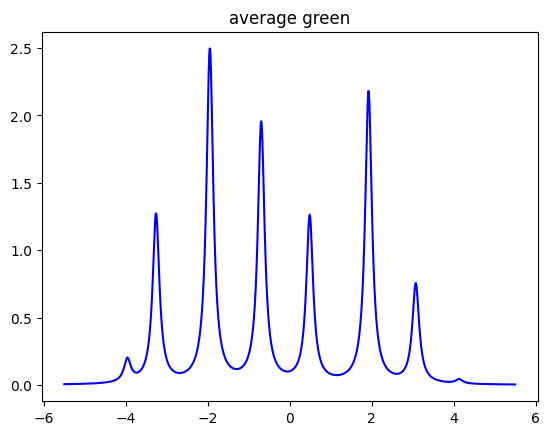

In [814]:
average_lanczos = np.zeros([2,10], dtype = complex)

for i in range(2):
    for j in range(len(lanczos_result1[i])):
        average_lanczos[i][j] = (lanczos_result1[i][j] + lanczos_result2[i][j])/2

average_green = CF(average_lanczos[0], average_lanczos[1])

w = np.linspace(-5.5,5.5,1000)-1e-1j 

plt.plot(w,np.imag(average_green(w)), label="green", color="blue") 
plt.title("average green")
plt.show()

## Two normal Lanczos and two normal green plot (Green 1 + Green 2)

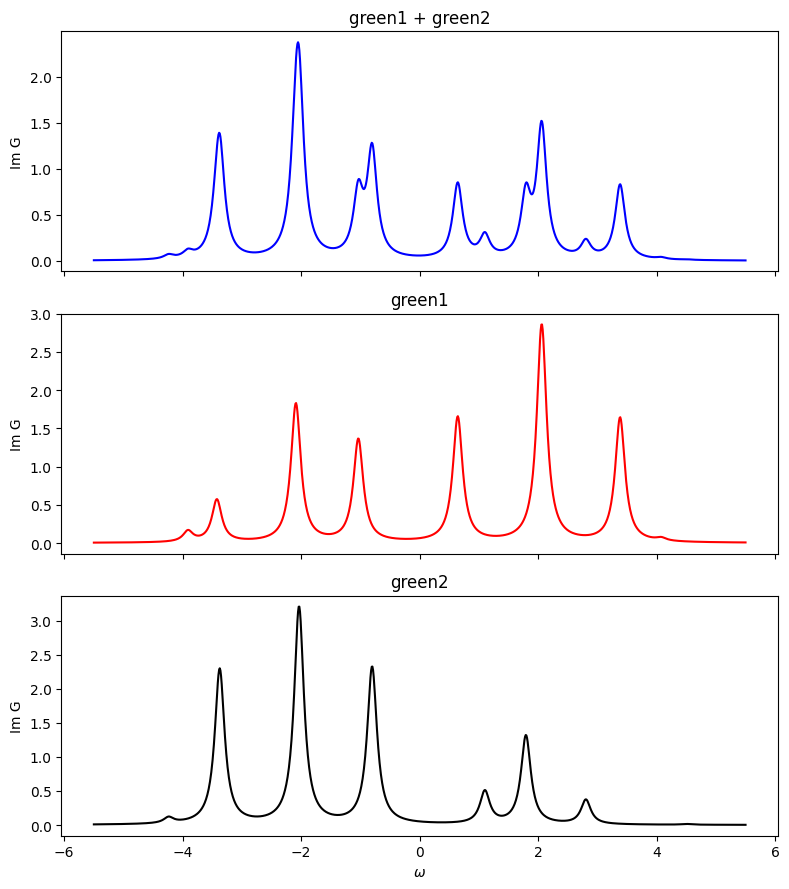

In [815]:
green1  = CF(lanczos_result1[0], lanczos_result1[1])
green2  = CF(lanczos_result2[0], lanczos_result2[1])

w = np.linspace(-5.5, 5.5, 1000) - 1e-1j
x = np.real(w)

fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

axs[0].plot(x, 0.5 * np.imag(green1(w))+ 0.5 *np.imag(green2(w)), color="blue")
axs[0].set_title("green1 + green2")
axs[0].set_ylabel("Im G")

axs[1].plot(x, np.imag(green1(w)), color="red")
axs[1].set_title("green1")
axs[1].set_ylabel("Im G")

axs[2].plot(x, np.imag(green2(w)), color="black")
axs[2].set_title("green2")
axs[2].set_ylabel("Im G")
axs[2].set_xlabel(r"$\omega$")

plt.tight_layout()
plt.show()

## Two different types of inner products:
- inner fswap: each Lanczos iteration toggle Fswap GS 
- inner product sum: return 0.5(<GS|O|GS>+<GS'|O|GS'>)

In [816]:
GS = vqe_hubbard_3sites.copy()

lanczos_sum = Lanczos(inner_product_sum(GS,AerEstimatorV2(),eps),Liouvillian_spo(eps),sum_spo(eps))
lanczos_result_sum = lanczos_sum(H,C0,12,1e-8)
green_sum = CF(lanczos_result_sum[0],lanczos_result_sum[1])

In [817]:
lanczos_fswap = Lanczos(inner_fswap(GS,AerEstimatorV2(),eps),Liouvillian_spo(eps),sum_spo(eps))
lanczos_result_fswap = lanczos_fswap(H,C0,10,1e-8)
green_fswap = CF(lanczos_result_fswap[0],lanczos_result_fswap[1])

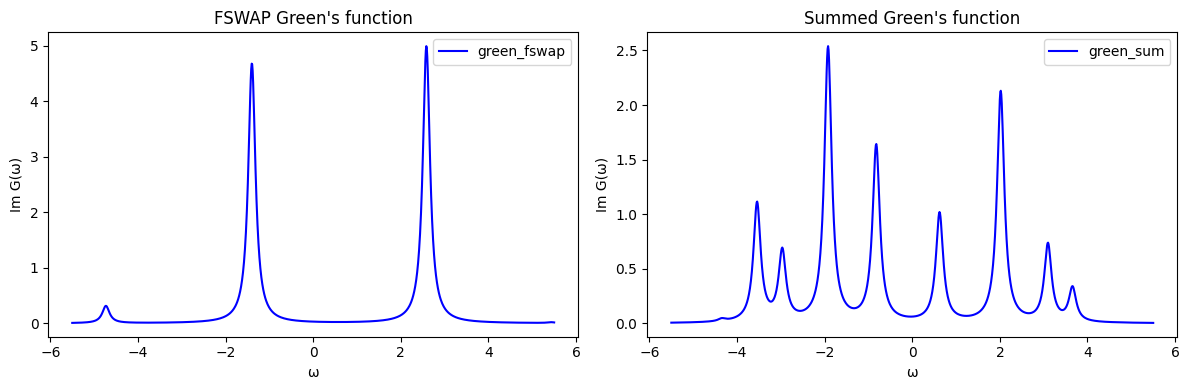

In [818]:
w = np.linspace(-5.5, 5.5, 1000) - 1e-1j

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(w.real, np.imag(green_fswap(w)), label="green_fswap", color="blue")
ax[0].set_title("FSWAP Green's function")
ax[0].set_xlabel("ω")
ax[0].set_ylabel("Im G(ω)")
ax[0].legend()

ax[1].plot(w.real, np.imag(green_sum(w)), label="green_sum", color="blue")
ax[1].set_title("Summed Green's function")
ax[1].set_xlabel("ω")
ax[1].set_ylabel("Im G(ω)")
ax[1].legend()

plt.tight_layout()
plt.show()